# Poke Balance Sentinel - EDA and Training\n
\n
Quick exploration and model training notebook.

In [4]:
from pathlib import Path
import sys
import pandas as pd

project_root = Path("..").resolve()
sys.path.append(str(project_root))

from src.preprocessing import load_data, add_power_creep_index, prepare_features

data_path = project_root / "data" / "pokemon_complete_2025.csv"
df = load_data(data_path)
df.head()

,pokedex_id,name,genus,generation,type_1,type_2,num_types,hp,attack,defense,...,is_dual_type,bmi,attack_defense_ratio,physical_total,special_total,offensive_total,defensive_total,gender_distribution,stat_tier,generation_num
0,1,bulbasaur,Seed Pokémon,I,grass,poison,2,45,49,49,...,True,14.1,1.00,98,130,159,159,88% Male / 12% Female,Below Average (300-399),1
1,2,ivysaur,Seed Pokémon,I,grass,poison,2,60,62,63,...,True,13.0,0.98,125,160,202,203,88% Male / 12% Female,Average (400-499),1
2,3,venusaur,Seed Pokémon,I,grass,poison,2,80,82,83,...,True,25.0,0.99,165,200,262,263,88% Male / 12% Female,Strong (500-599),1
3,4,charmander,Lizard Pokémon,I,fire,NaN,1,39,52,43,...,False,23.6,1.21,95,110,177,132,88% Male / 12% Female,Below Average (300-399),1
4,5,charmeleon,Flame Pokémon,I,fire,NaN,1,58,64,58,...,False,15.7,1.10,122,145,224,181,88% Male / 12% Female,Average (400-499),1


In [6]:
df_pci = add_power_creep_index(df)
df_pci[["name", "generation", "base_stat_total", "power_creep_index"]].head()

,name,generation,base_stat_total,power_creep_index
0,bulbasaur,I,318,0.780096
1,ivysaur,I,405,0.993518
2,venusaur,I,525,1.287894
3,charmander,I,309,0.758017
4,charmeleon,I,405,0.993518


In [9]:
from sklearn.model_selection import train_test_split
from src.models import train_random_forest, evaluate_regressor

X = prepare_features(df_pci)
y = df_pci["power_creep_index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = train_random_forest(X_train, y_train)
metrics = evaluate_regressor(model, X_test, y_test)
metrics

{'rmse': 0.0158537655913712,
 'mae': 0.010708545021179766,
 'r2': 0.9962898054392375}

C:\Users\User\AppData\Local\Temp\ipykernel_24704\3368122344.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='generation_num', y='base_stat_total', data=df, palette='viridis')


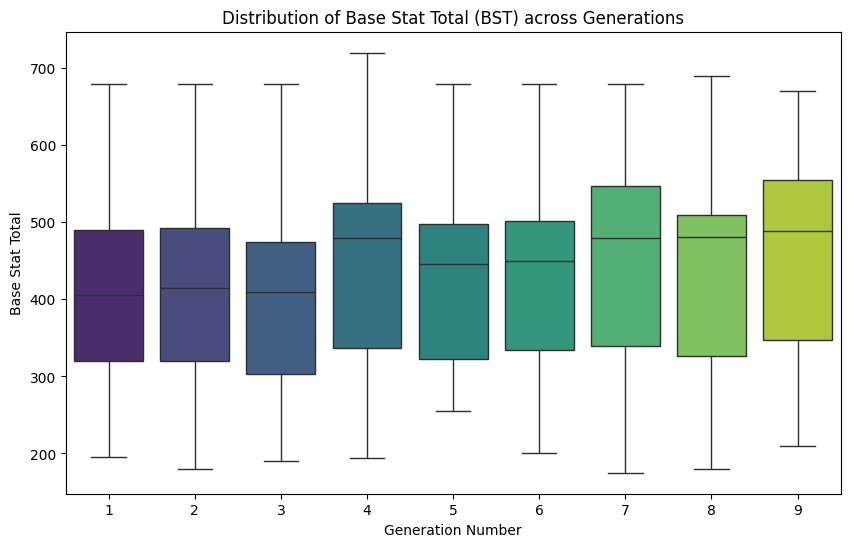

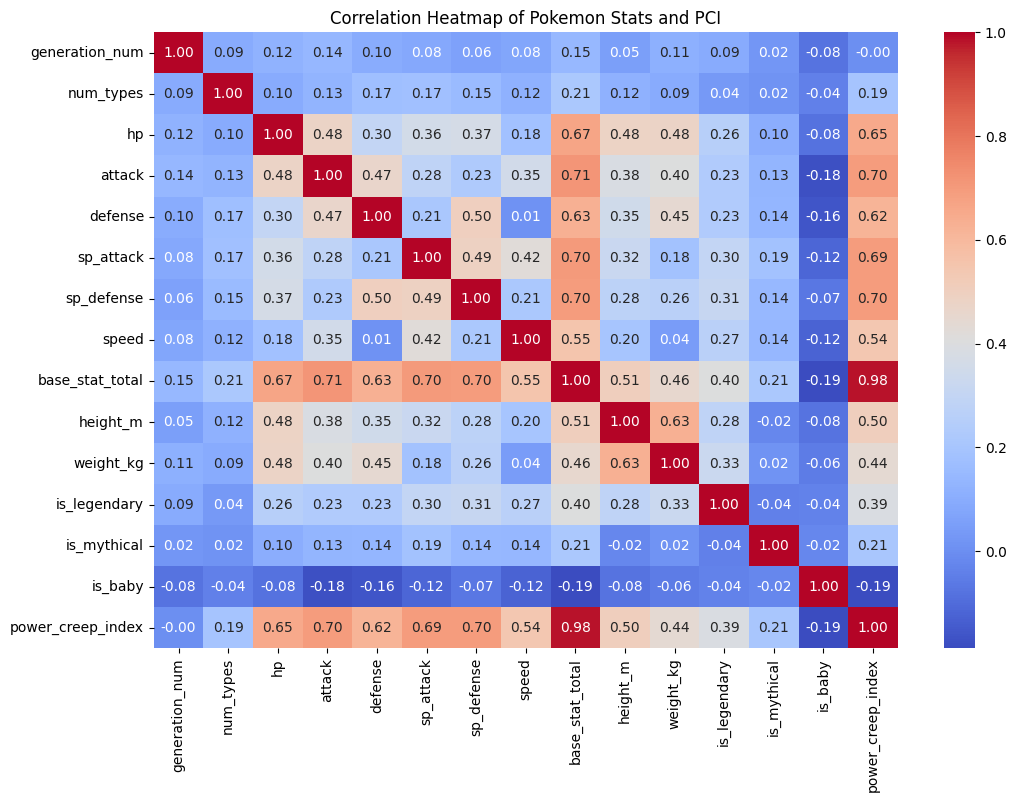

Top 10 Pokemon by Power Creep Index (PCI):
         name  generation_num  base_stat_total  power_creep_index
383  rayquaza               3              680           1.684311
248     lugia               2              680           1.670023
249     ho-oh               2              680           1.670023
149    mewtwo               1              680           1.668129
288   slaking               3              670           1.659542
381    kyogre               3              670           1.659542
382   groudon               3              670           1.659542
492    arceus               4              720           1.615907
643    zekrom               5              680           1.597157
642  reshiram               5              680           1.597157


C:\Users\User\AppData\Local\Temp\ipykernel_24704\3368122344.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='power_creep_index', y='name', data=top_pci, palette='magma')


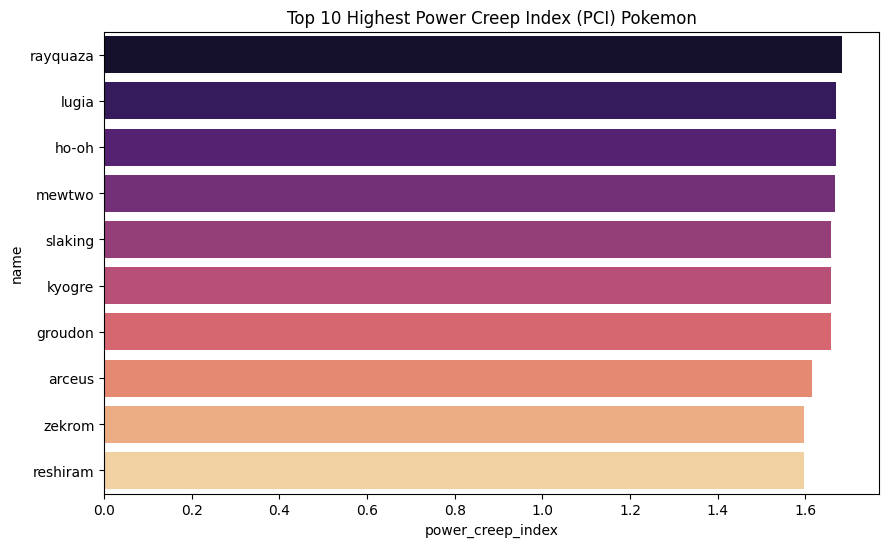

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.preprocessing import load_data, add_power_creep_index, FEATURE_COLUMNS, TARGET_COLUMN

# Load and prepare data
df = load_data('C:\\Github Projects\\Predictive-Meta-Balance-System-for-Pokemon\\poke-balance-sentinel\\data\\pokemon_complete_2025.csv')
df = add_power_creep_index(df)

# --- Visualization 1: Power Creep over Generations ---
# This proves the "Power Creep" trend to your lecturer.
plt.figure(figsize=(10, 6))
sns.boxplot(x='generation_num', y='base_stat_total', data=df, palette='viridis')
plt.title('Distribution of Base Stat Total (BST) across Generations')
plt.xlabel('Generation Number')
plt.ylabel('Base Stat Total')
plt.show()

# --- Visualization 2: Feature Correlation Heatmap ---
# This shows which stats drive the Power Creep Index (PCI).
plt.figure(figsize=(12, 8))
correlation_cols = FEATURE_COLUMNS + [TARGET_COLUMN]
corr_matrix = df[correlation_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Pokemon Stats and PCI')
plt.show()

# --- Visualization 3: Identifying Meta-Outliers (Broken Pokemon) ---
# Displays the top 10 Pokemon with the highest PCI.
top_pci = df[['name', 'generation_num', 'base_stat_total', 'power_creep_index']].sort_values(by='power_creep_index', ascending=False).head(10)
print("Top 10 Pokemon by Power Creep Index (PCI):")
print(top_pci)

# Optional: Bar chart for Top 10 PCI
plt.figure(figsize=(10, 6))
sns.barplot(x='power_creep_index', y='name', data=top_pci, palette='magma')
plt.title('Top 10 Highest Power Creep Index (PCI) Pokemon')
plt.show()